In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn. datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# in k means clustering we find k based on elbow method

# centers means k value
X, y_true = make_blobs(
  n_samples=500, 
  centers=3, 
  cluster_std=4,
  random_state=42
)

In [4]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [5]:
df

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [7]:
inertia = []
K_range = range(1, 11)

In [8]:
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans. fit(X_scaled)
  inertia.append (kmeans.inertia_)

In [9]:
inertia

[999.9999999999993,
 528.8064432605648,
 294.43770686781863,
 250.4552469653445,
 216.88110656982602,
 185.274406751959,
 156.70879996290446,
 135.6260345311525,
 129.10396348239811,
 119.94101297104989]

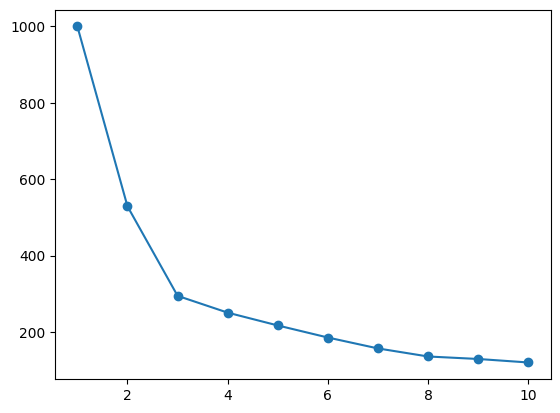

In [10]:
plt.plot(K_range, inertia, marker='o')

In [11]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

cluster_labels = kmeans_final. fit_predict(X_scaled)

In [12]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

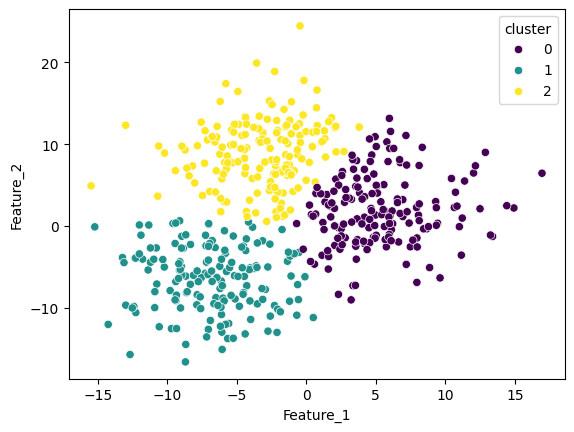

In [13]:
sns. scatterplot(
  x = df ['Feature_1'],
  y = df['Feature_2'],
  hue = df['cluster'],
  palette = ('viridis')
)

### Make_Moons by k-means

In [14]:
from sklearn.datasets import make_moons

In [15]:
X, y_true = make_moons(n_samples=500, noise = 0.1, random_state=42)

In [16]:
from sklearn.cluster import KMeans, DBSCAN

In [17]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [18]:
scaler = StandardScaler()
X_scaled = scaler. fit_transform(df)

In [19]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans. fit_predict(X_scaled)

In [20]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

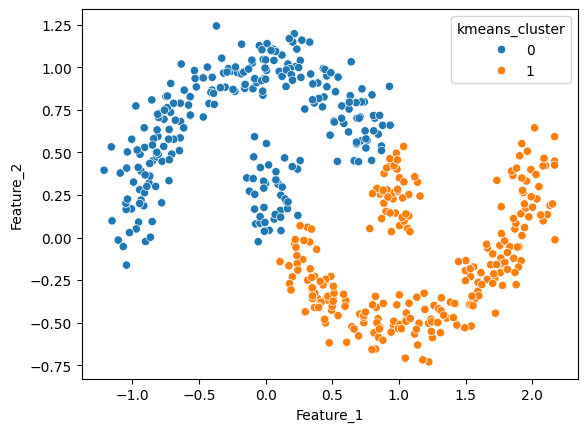

In [21]:
sns.scatterplot(
  x=df['Feature_1'], 
  y=df['Feature_2'], 
  hue=df['kmeans_cluster'],
  palette='tab10'
)

### Make_Moons by DBScan algorithm

In [22]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan. fit_predict(X_scaled)

In [23]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

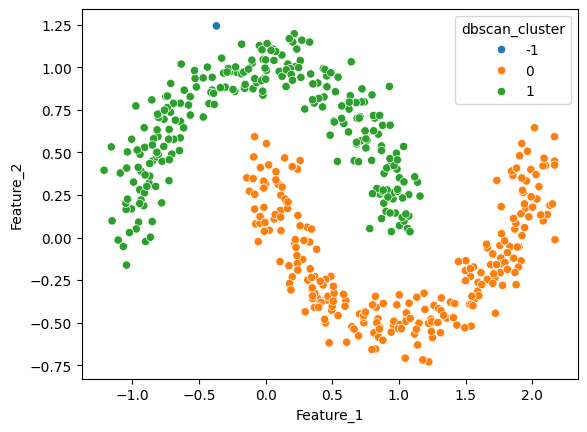

In [24]:
sns. scatterplot(
  x=df ['Feature_1'], 
  y=df['Feature_2'], 
  hue=df['dbscan_cluster'],
  palette='tab10'
)